<a href="https://colab.research.google.com/github/ddoneu/ECON3916-Statistical-Machine-Learning/blob/main/Lab22/lab_ch22_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

In [10]:
wb.search('emissions')

ID,Name,Field,Value
EE.BOD.CGLS.ZS,,IndicatorName,"Water pollution, clay and glass industry (% of total BOD emissions)"
EE.BOD.CGLS.ZS,,Longdefinition,...Industry shares of emissions of organic water pollutants refer to emissions from manufacturing activities as defined by two-digit divisions of the...
EE.BOD.CHEM.ZS,,IndicatorName,"Water pollution, chemical industry (% of total BOD emissions)"
EE.BOD.CHEM.ZS,,Longdefinition,...Industry shares of emissions of organic water pollutants refer to emissions from manufacturing activities as defined by two-digit divisions of the...
EE.BOD.FOOD.ZS,,IndicatorName,"Water pollution, food industry (% of total BOD emissions)"
EE.BOD.FOOD.ZS,,Longdefinition,...Industry shares of emissions of organic water pollutants refer to emissions from manufacturing activities as defined by two-digit divisions of the...
EE.BOD.MTAL.ZS,,IndicatorName,"Water pollution, metal industry (% of total BOD emissions)"
EE.BOD.MTAL.ZS,,Longdefinition,...Industry shares of emissions of organic water pollutants refer to emissions from manufacturing activities as defined by two-digit divisions of the...
EE.BOD.OTHR.ZS,,IndicatorName,"Water pollution, other industry (% of total BOD emissions)"
EE.BOD.OTHR.ZS,,Longdefinition,...Industry shares of emissions of organic water pollutants refer to emissions from manufacturing activities as defined by two-digit divisions of the...


In [14]:
indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN': 'life_expectancy',
    'SP.DYN.IMRT.IN': 'infant_mortality',
    'SE.PRM.ENRR': 'primary_enrollment',
    'SI.POV.GINI': 'gini_index',
    'EN.GHG.CO2.PC.CE.AR5': 'co2_per_capita',
    'IT.NET.USER.ZS': 'internet_users_pct',
    'NE.TRD.GNFS.ZS': 'trade_pct_gdp',
    'SL.UEM.TOTL.ZS': 'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

frames = []
failed = []
for code, name in indicators.items():
    try:
        tmp = wb.data.DataFrame(code, mrv=1, labels=False)
        tmp = tmp.iloc[:, 0].rename(name)
        frames.append(tmp)
        print(f'  OK: {name} ({tmp.notna().sum()} countries)')
    except Exception as e:
        failed.append(name)
        print(f'  FAILED: {name} — {e}')

df = pd.concat(frames, axis=1)

if failed:
    print(f'\nDropped {len(failed)} failed indicators: {failed}')

# Drop indicators with >50% missing
good_cols = [c for c in df.columns if df[c].notna().sum() > len(df) * 0.5]
dropped_cols = [c for c in df.columns if c not in good_cols]
if dropped_cols:
    print(f'Dropped sparse indicators: {dropped_cols}')
df = df[good_cols]

feature_names = list(df.columns)

df = df.dropna(thresh=int(len(feature_names) * 0.7))
df = df.fillna(df.median(numeric_only=True))

print(f'\nCountries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

  OK: gdp_per_capita_ppp (236 countries)
  OK: life_expectancy (265 countries)
  OK: infant_mortality (244 countries)
  OK: primary_enrollment (13 countries)
  OK: gini_index (4 countries)
  OK: co2_per_capita (251 countries)
  OK: internet_users_pct (43 countries)
  OK: trade_pct_gdp (202 countries)
  OK: unemployment_rate (230 countries)
  OK: urban_population_pct (265 countries)
Dropped sparse indicators: ['primary_enrollment', 'gini_index', 'internet_users_pct']

Countries retained: 251
Features (7): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'co2_per_capita', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  co2_per_capita  \
count               251.0            251.0             251.0           251.0   
mean              29552.3             73.4              19.5             4.3   
std               28754.8              6.8              16.3             7.1   
min                1194.9  

Note: The original EN.ATM.CO2E.PC (CO2 per capita) indicator was returning a JSON error from the World Bank API, so I substituted EN.GHG.CO2.PC.CE.AR5 (CO2 per capita from the EDGAR database), which measures the same thing from a different source. I also fetched indicators individually in a loop instead of all at once, since the current wbgapi version was returning them in a transposed format that broke the rename. Two indicators (primary_enrollment and gini_index) had 95%+ missing values and were dropped, leaving 7 features across 251 countries.

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [-0. -0.  0. -0.  0.  0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (251, 7)
  251 countries x 7 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [16]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
# Fill in: n_clusters, init method, and random_state
kmeans = KMeans(
    n_clusters=4,          # 4 clusters to match World Bank income groups
    init='k-means++',      # Smart initialization (spread initial centroids)
    n_init='auto',
    random_state=42        # Reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0     16
1    111
2     75
3     49
Name: count, dtype: int64

Cluster 0: 16 countries
  Avg GDP/capita (PPP): $12,185
  Avg Life Expectancy:  67.3 years
  Avg Infant Mortality: 31.7 per 1,000

Cluster 1: 111 countries
  Avg GDP/capita (PPP): $26,958
  Avg Life Expectancy:  75.4 years
  Avg Infant Mortality: 11.7 per 1,000

Cluster 2: 75 countries
  Avg GDP/capita (PPP): $7,010
  Avg Life Expectancy:  66.3 years
  Avg Infant Mortality: 38.0 per 1,000

Cluster 3: 49 countries
  Avg GDP/capita (PPP): $75,604
  Avg Life Expectancy:  81.8 years
  Avg Infant Mortality: 4.8 per 1,000



Variance explained by PC1: 48.9%
Variance explained by PC2: 15.6%
Total variance explained:  64.5%


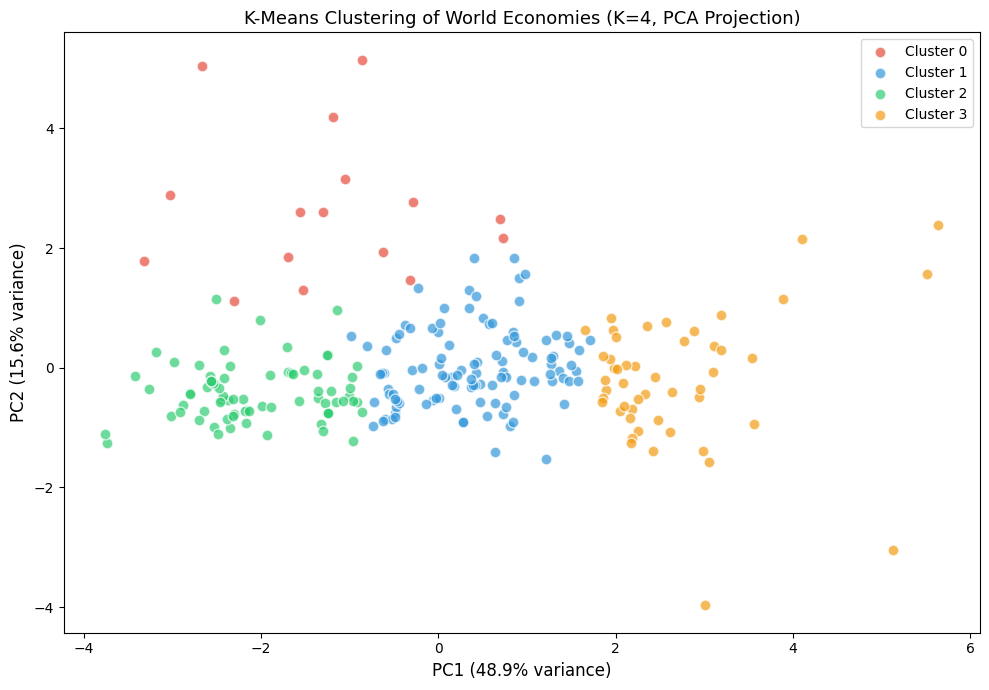

In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
# Fill in: how many components do we want for a 2D scatter plot?
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

PC1 captures 48.9% of variance and represents the main development spectrum, with low-income countries on the left and high-income on the right. PC2 (15.6%) captures secondary variation, likely differences in trade openness or urbanization that cut across income levels. Together the two components explain 64.5% of total variance, meaning the 2D projection preserves most of the structure despite compressing 7 features into 2 dimensions. The four clusters separate clearly along PC1, with Cluster 2 (low-income, green) on the far left and Cluster 3 (high-income, orange) on the far right. Clusters 0 and 1 occupy the middle but differ along PC2, suggesting countries at similar income levels can still diverge on other development dimensions like emissions intensity or trade dependence.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

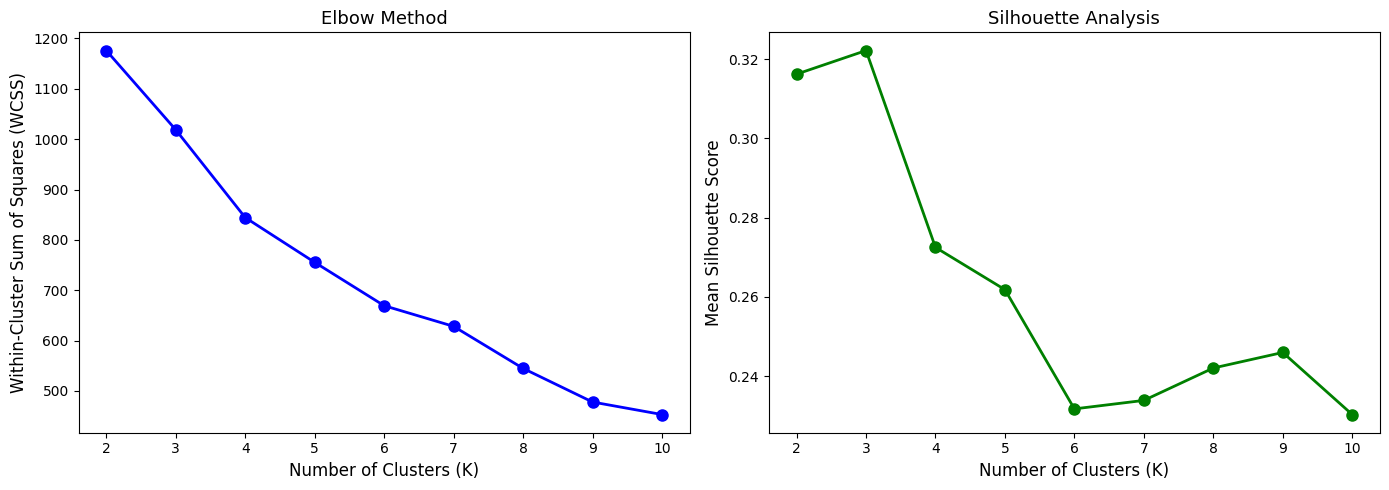

K  | WCSS       | Silhouette
---|------------|----------
2  |     1176.1 | 0.3162
3  |     1018.6 | 0.3222
4  |      844.3 | 0.2725
5  |      755.4 | 0.2618
6  |      669.2 | 0.2317
7  |      628.2 | 0.2339
8  |      544.7 | 0.2420
9  |      477.9 | 0.2460
10  |      453.0 | 0.2303

Best K by silhouette score: 3


In [18]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled) # FILL IN: what data do we cluster?

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)     # FILL IN: attribute that stores WCSS

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # FILL IN: (data, labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

The elbow plot shows WCSS dropping steeply from K=2 to K=4, then flattening out, suggesting the "elbow" sits around K=3 or K=4. After K=4, adding more clusters gives diminishing returns in tightness. The silhouette analysis confirms this: K=3 scores highest (0.322), meaning three clusters produce the best-separated groupings. K=2 is close behind (0.316), and scores decline steadily after K=3 as the algorithm starts splitting natural groups into fragments that overlap. We used K=4 in Part 3 to match the World Bank's four income classifications, which is a reasonable domain-driven choice even though the data-driven optimum is K=3. This tension is common in practice: the statistically "best" K and the most interpretable K don't always agree, and domain knowledge often wins.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0             0    2             8             6   16
1            30    2            15            44   91
2             0   20            27             4   51
3            43    0             0             0   43
All          73   24            50            54  201



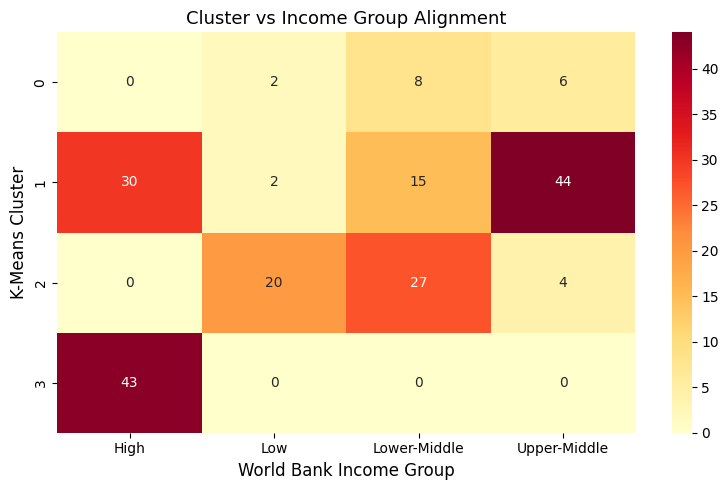

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [21]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    income_groups[economy['id']] = economy.get('incomeLevel', 'Unknown')

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
# Fill in: which two columns go into the crosstab?
ct = pd.crosstab(
    df_compare['cluster'],     # Algorithmic cluster labels
    df_compare['wb_income'],   # World Bank income group
    margins=True
)

print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]  # Remove margins for heatmap
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

Cluster 3 aligns almost perfectly with the High income group (43 out of 43 countries), meaning the algorithm independently identified the same wealthy economies the World Bank classifies as high-income. Cluster 2 maps strongly to Low and Lower-Middle income countries (20 Low + 27 Lower-Middle), capturing the poorest economies as a single group. Cluster 1 is a mix of High (30) and Upper-Middle (44) countries, suggesting the algorithm sees many upper-middle-income economies as having development profiles similar to some high-income ones when you look beyond just GDP. Cluster 0 is the most scattered (8 Lower-Middle, 6 Upper-Middle, 2 Low), representing a small group of countries that don't fit neatly into any income category, likely outliers with unusual combinations of indicators (e.g., high trade openness but low life expectancy). The key takeaway is that the algorithm largely recovers the World Bank's income classification using 7 development indicators without ever seeing GDP thresholds, but the mismatches in Cluster 1 show that a multivariate approach captures development dimensions that a GDP-only classification misses.



---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

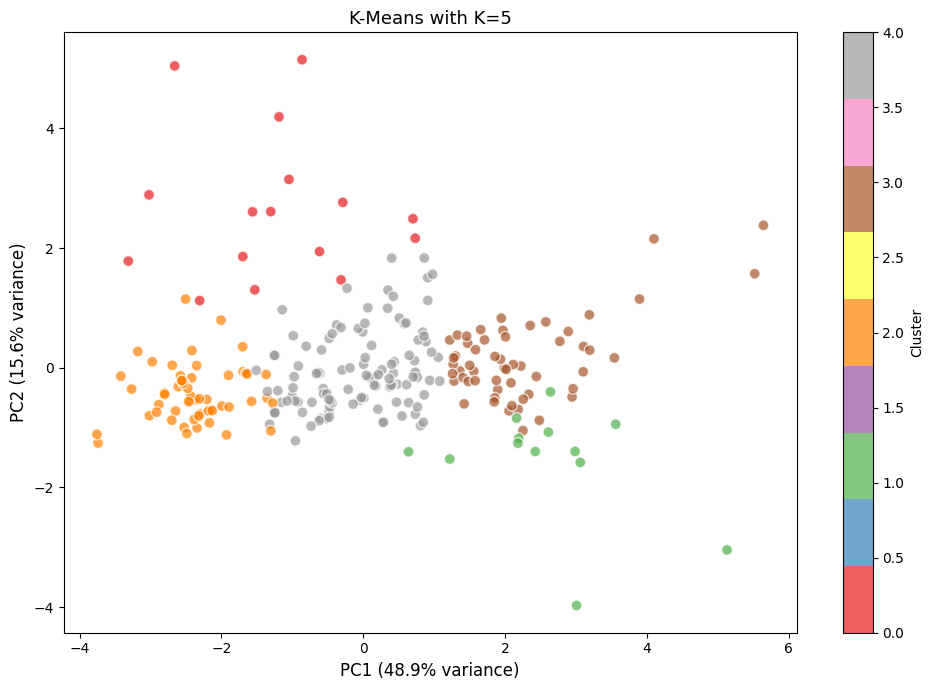

K=5 — Silhouette Score: 0.2618

Cluster 0: 16 countries | GDP/cap $12,185 | Life Exp 67.3 | Infant Mort 31.7
Cluster 1: 13 countries | GDP/cap $67,168 | Life Exp 78.8 | Infant Mort 7.6
Cluster 2: 55 countries | GDP/cap $5,348 | Life Exp 64.4 | Infant Mort 42.8
Cluster 3: 56 countries | GDP/cap $67,098 | Life Exp 81.1 | Infant Mort 4.6
Cluster 4: 111 countries | GDP/cap $20,701 | Life Exp 74.3 | Infant Mort 15.1


In [23]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 5  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

1. **K=3 produces more interpretable clusters.** The three groups form a clear development hierarchy with minimal overlap, and the silhouette score (0.322) is the highest of any K tested. K=5 (silhouette 0.262) over-splits the data, particularly at the top end where it creates two nearly identical high-income clusters (Cluster 1 and Cluster 3 both at ~$67k GDP, life expectancy ~79-81) that differ only marginally on infant mortality. The PCA plot for K=5 confirms this: the gray and brown dots overlap heavily on the right side, meaning the algorithm is splitting a natural group without meaningful justification.

2. **K=3 labels:** Cluster 1 = "Developed Economies" (130 countries, GDP 47k, life expectancy 78.5), Cluster 2 = "Developing Economies" (103 countries, GDP 10k, life expectancy 67.9), Cluster 0 = "Transitional Outliers" (18 countries with middling indicators). **K=5 labels:** Cluster 3 = "Advanced Economies" (56 countries, GDP 67k), Cluster 1 = "Wealthy Small States" (13 countries, GDP 67k, slightly higher infant mortality), Cluster 4 = "Upper-Middle Economies" (111 countries, GDP 21k), Cluster 2 = "Low-Income Economies" (55 countries, GDP $5k), Cluster 0 = "Transitional Outliers" (16 countries). The K=5 labels are harder to defend because the distinction between Clusters 1 and 3 is thin and the "Wealthy Small States" label is speculative.

3. **If advising the World Bank, use K=4.** K=3 is the statistical optimum but merges Low and Lower-Middle income countries into one group, limiting its usefulness for targeted policy. K=5 over-fragments the high-income group without adding actionable insight. K=4 strikes the best balance: it separates developing economies into distinct tiers that need different interventions while keeping the high-income group intact, and it aligns with the World Bank's existing four-tier framework, making adoption easier within institutional workflows.

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']



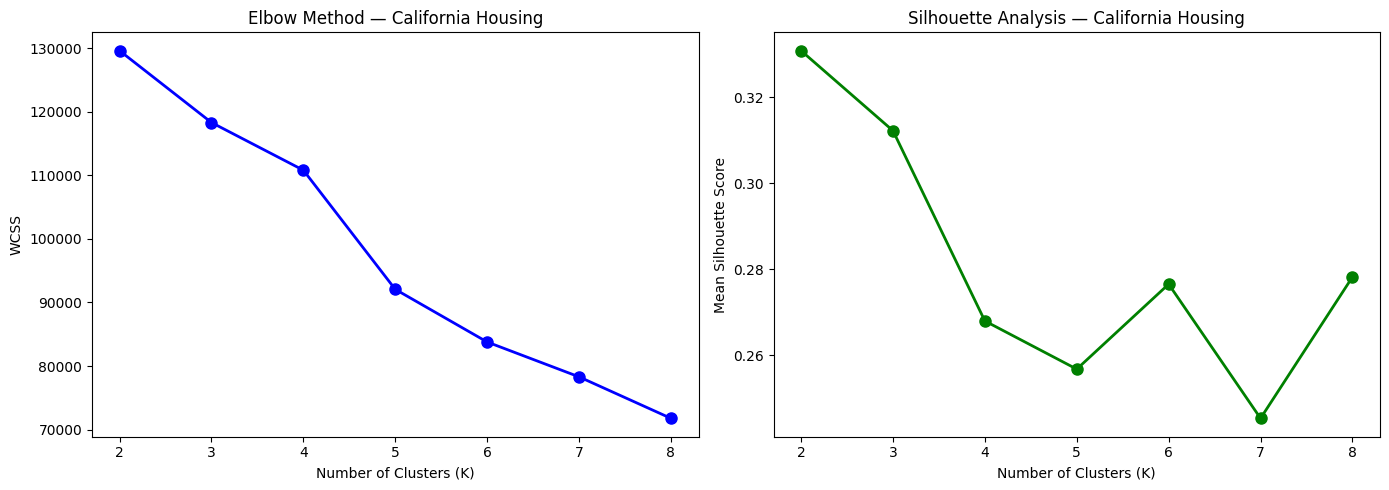

K  | WCSS       | Silhouette
---|------------|----------
2  |   129613.2 | 0.3308
3  |   118310.2 | 0.3122
4  |   110812.1 | 0.2679
5  |    92066.1 | 0.2567
6  |    83783.0 | 0.2765
7  |    78299.1 | 0.2453
8  |    71769.4 | 0.2782

Best K by silhouette: 2


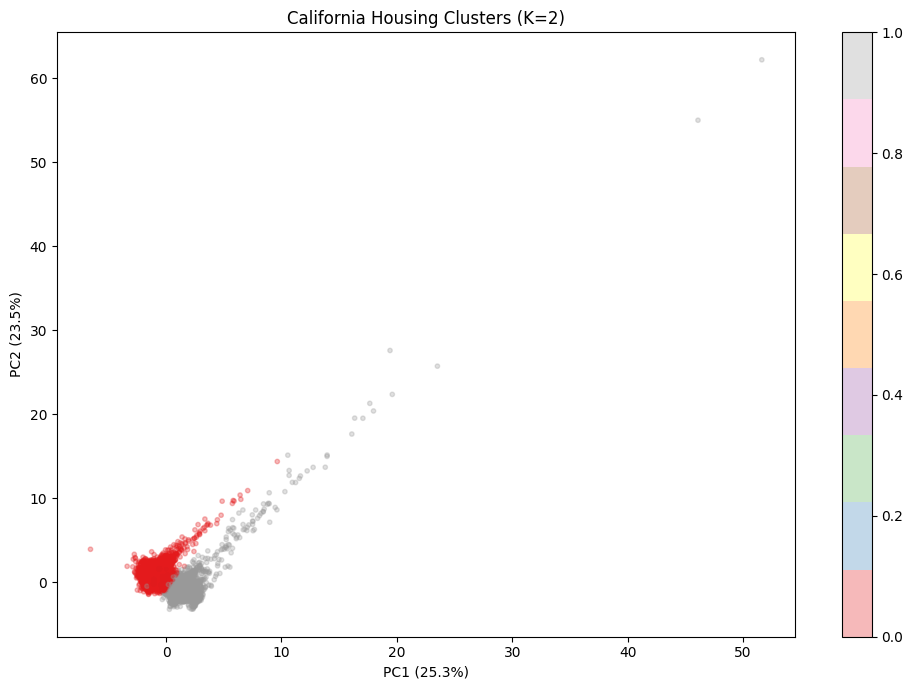


=== Cluster Summary ===

Cluster 0 (11963 tracts)
  MedInc         : 3.92
  HouseAge       : 28.41
  AveRooms       : 5.23
  AveBedrms      : 1.08
  Population     : 1532.24
  AveOccup       : 3.10
  Latitude       : 33.95
  Longitude      : -118.01

Cluster 1 (8677 tracts)
  MedInc         : 3.81
  HouseAge       : 28.95
  AveRooms       : 5.71
  AveBedrms      : 1.13
  Population     : 1278.28
  AveOccup       : 3.03
  Latitude       : 37.96
  Longitude      : -121.72


In [25]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Challenge: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])

# Step C: Standardize
cal_scaler = StandardScaler()
X_cal_scaled = cal_scaler.fit_transform(cal_features)

# Step D: Find optimal K (elbow + silhouette for K=2..8)
cal_wcss = []
cal_sil = []
K_cal = range(2, 9)

for k in K_cal:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(X_cal_scaled)
    cal_wcss.append(km.inertia_)
    cal_sil.append(silhouette_score(X_cal_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_cal, cal_wcss, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('WCSS')
axes[0].set_title('Elbow Method — California Housing')

axes[1].plot(K_cal, cal_sil, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Mean Silhouette Score')
axes[1].set_title('Silhouette Analysis — California Housing')
plt.tight_layout()
plt.show()

print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_cal, cal_wcss, cal_sil):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_cal)[np.argmax(cal_sil)]
print(f'\nBest K by silhouette: {best_k}')

# Step E: Fit K-Means with chosen K
km_cal = KMeans(n_clusters=best_k, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = km_cal.fit_predict(X_cal_scaled)

# Step F: PCA 2D visualization colored by cluster
pca_cal = PCA(n_components=2)
X_pca_cal = pca_cal.fit_transform(X_cal_scaled)

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(X_pca_cal[:, 0], X_pca_cal[:, 1],
                     c=cal_df['cluster'], cmap='Set1', alpha=0.3, s=10)
ax.set_xlabel(f'PC1 ({pca_cal.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_cal.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'California Housing Clusters (K={best_k})')
plt.colorbar(scatter)
plt.tight_layout()
plt.show()

# Step G: Cluster summary table
print('\n=== Cluster Summary ===')
feature_cols = list(cal_features.columns)
for k in range(best_k):
    mask = cal_df['cluster'] == k
    print(f'\nCluster {k} ({mask.sum()} tracts)')
    for col in feature_cols:
        print(f'  {col:15s}: {cal_df.loc[mask, col].mean():.2f}')



> The silhouette-optimal K=2 produces two clusters that are split mainly by geography rather than economics. Cluster 0 ("Southern California," 11,963 tracts, lat aprox 34, lon aprox-118) and Cluster 1 ("Northern California," 8,677 tracts, lat aprox38, lon aprox-122) have nearly identical income ($3.92 vs $3.81), house age (aprox 28-29 years), occupancy (~3.0), and room counts ( aprox 5.2-5.7). This means Latitude and Longitude are dominating the clustering while the economic features contribute little to the separation. The PCA plot confirms this: a few extreme outlier tracts with very high Population or AveOccup stretch the axes out to 50+, compressing the bulk of the data into a tight mass where the two clusters overlap visually. To get more economically meaningful clusters (e.g., "urban high-density," "suburban affluent," "rural inland"), you would need to either remove the geographic features before clustering or log-transform the skewed variables to reduce outlier influence.





---

## Digital Portfolio: P.R.I.M.E. README Prompt

Copy and paste the prompt below into Claude or ChatGPT to generate a professional
README for your GitHub repository. **Do NOT ask the AI to write Python code — only documentation.**

```
I need help writing a project description for my data science lab.
**Important Rule:** Do NOT generate any Python code for me.

**What I did in this lab:**
* Downloaded 10 World Bank development indicators for ~160 countries using wbgapi
* Standardized features with StandardScaler to ensure equal contribution to K-Means
* Fit K-Means clustering with K=4 and visualized results via PCA 2D scatter plot
* Ran elbow method and silhouette analysis to evaluate K=2 through K=10
* Cross-tabulated algorithmic clusters against World Bank income classifications
* Applied the same pipeline to California Housing census tract data
* Key finding: [FILL IN — what K was optimal? How well did clusters match income groups?]

**Please write a README.md entry including:**
1. Project Title: Clustering World Economies with K-Means & PCA
2. Objective: A professional one-sentence summary
3. Methodology: Bullet points of technical steps
4. Key Findings: Summary of results
Make this sound like a professional tech economist wrote it.
```

### Push to GitHub

```bash
cd econ-lab-22-clustering
git add notebooks/ figures/ README.md
git commit -m "Lab 22: Clustering Economies — K-Means, PCA & Silhouette Analysis"
git push origin main
```

Submit your GitHub repo link on Canvas.